In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
mobile_sales = pd.read_csv('/content/drive/MyDrive/Time Series and Recsys data/time_series_2_data.csv')

In [ ]:
mobile_sales = mobile_sales.set_index('DATE')

In [ ]:
mobile_sales.index = pd.to_datetime(mobile_sales.index)

In [ ]:
mobile_sales = mobile_sales.asfreq('MS')

In [ ]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6802.44
2001-02-01,6802.44
2001-03-01,7332.00
2001-04-01,7332.00
2001-05-01,8240.00


<Axes: xlabel='DATE'>

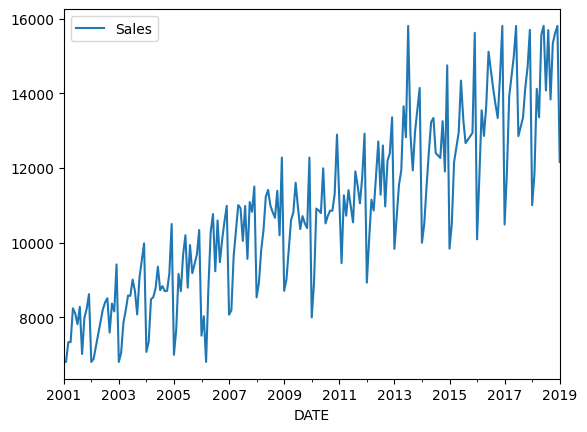

In [ ]:
mobile_sales.plot()

<Figure size 800x400 with 0 Axes>

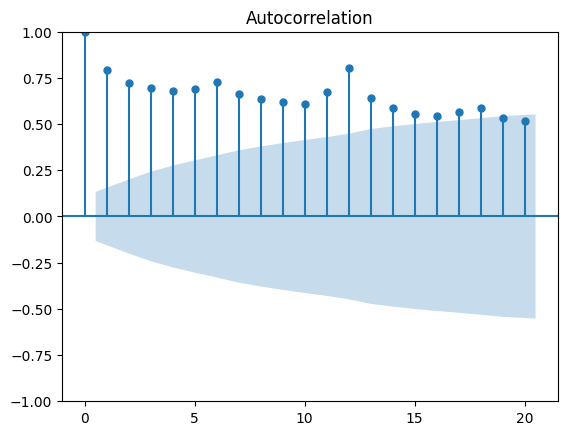

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,4))
plot_acf(mobile_sales, lags=20)
plt.show()

<Figure size 800x400 with 0 Axes>

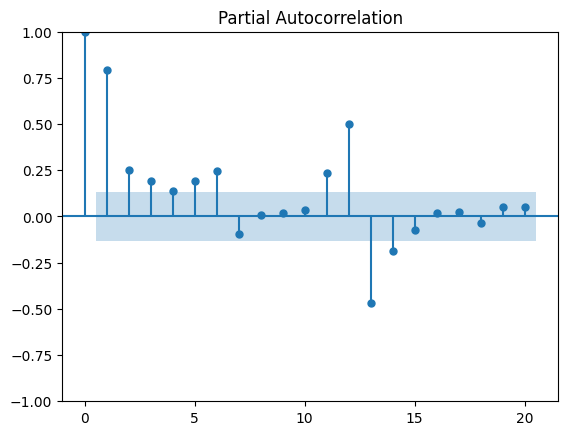

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(8,4))
plot_pacf(mobile_sales, lags=20)
plt.show()

In [ ]:
train_x = mobile_sales.iloc[:193]
test_x = mobile_sales.iloc[193:]

<Axes: xlabel='DATE'>

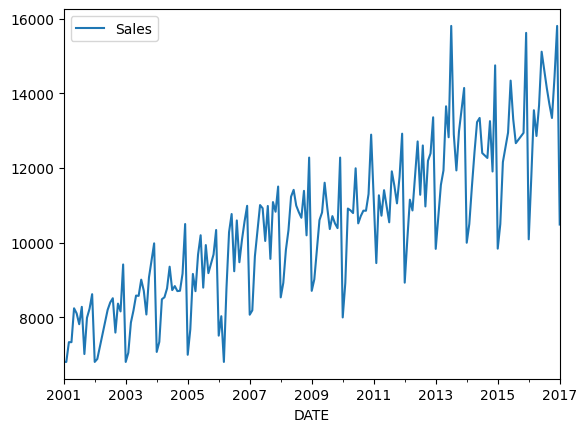

In [ ]:
train_x.plot()

<Axes: xlabel='DATE'>

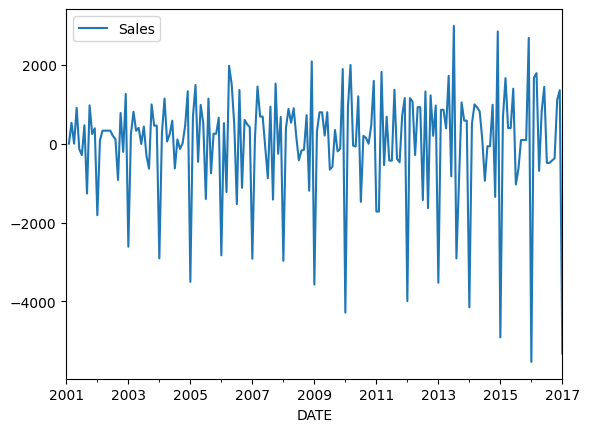

In [ ]:
train_x.diff(1).plot()

In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(train_x.Sales)

Sequence is not stationary


In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(train_x.Sales.diff(1).dropna())

Sequence is stationary


<Axes: xlabel='DATE'>

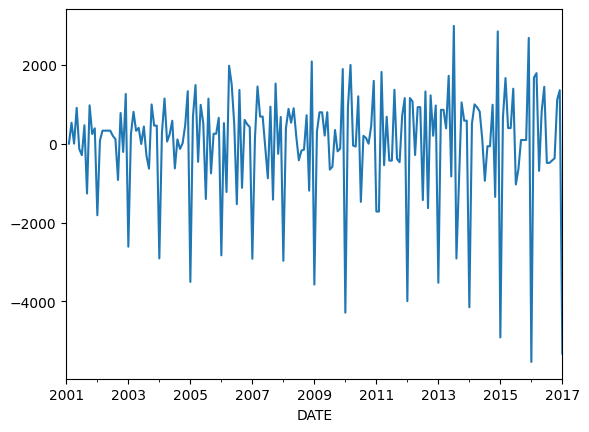

In [ ]:
train_x.Sales.diff().plot()

<Figure size 800x400 with 0 Axes>

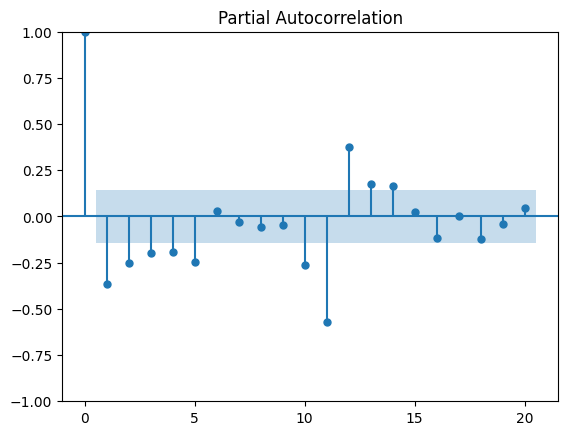

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

# 1. Create the differenced series
diff_series = train_x['Sales'].diff().dropna()

# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_pacf(diff_series, lags=20)
plt.show()

<Figure size 800x400 with 0 Axes>

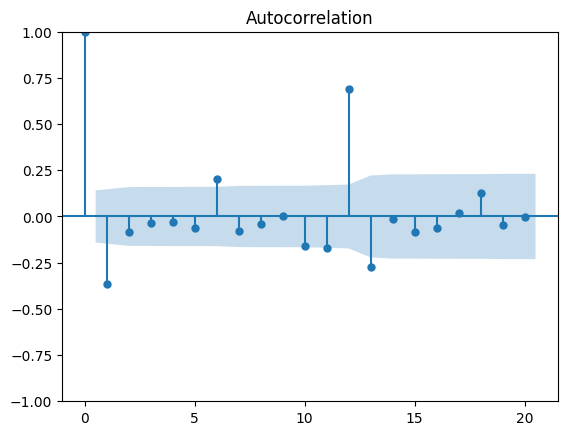

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

# 1. Create the differenced series
diff_series = train_x['Sales'].diff().dropna()

# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_acf(diff_series, lags=20)
plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(diff_series, order=(5, 1, 1))
model = model.fit(disp=False)

# Step 3: Optional - one-step forecast
forecast_1 = model.forecast(steps=24)

In [ ]:
forecast_1

,predicted_mean
2017-02-01,2432.297714
2017-03-01,496.998967
2017-04-01,123.765573
2017-05-01,181.035519
2017-06-01,54.828494
2017-07-01,-241.653496
2017-08-01,-89.962302
2017-09-01,-16.277835
2017-10-01,14.223995
2017-11-01,33.575102


In [ ]:
last_observed = train_x['Sales'].iloc[-1]

In [ ]:
last_observed

np.float64(10485.0)

In [ ]:
forecast_1

,predicted_mean
2017-02-01,2432.297714
2017-03-01,496.998967
2017-04-01,123.765573
2017-05-01,181.035519
2017-06-01,54.828494
2017-07-01,-241.653496
2017-08-01,-89.962302
2017-09-01,-16.277835
2017-10-01,14.223995
2017-11-01,33.575102


In [ ]:
forecast_original = pd.Series(forecast_1).cumsum() + last_observed

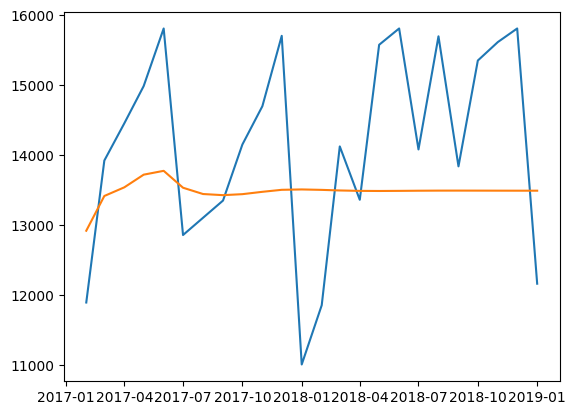

In [ ]:
plt.plot(test_x,label='test_actual')
plt.plot(forecast_original, label='test_pred')

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
len(test_x)

24

In [ ]:
model = SARIMAX(train_x.Sales, order=(5, 1, 1))
model = model.fit()

# Step 3: Optional - one-step forecast
forecast_1 = model.forecast(steps=24)

In [ ]:
forecast_1

,predicted_mean
2017-02-01,12832.637561
2017-03-01,13344.286721
2017-04-01,13508.078705
2017-05-01,13644.359301
2017-06-01,13752.774117
2017-07-01,13534.648132
2017-08-01,13438.867781
2017-09-01,13412.733179
2017-10-01,13419.096994
2017-11-01,13442.756288


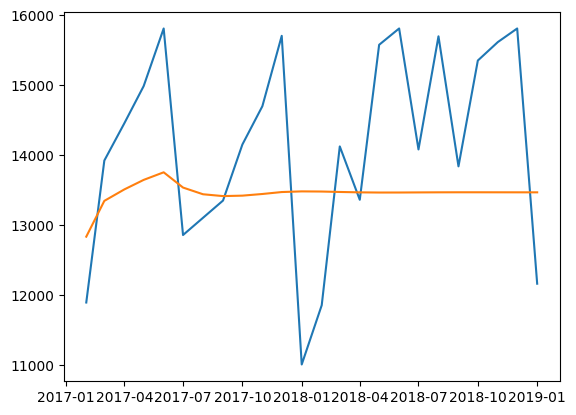

In [ ]:
plt.plot(test_x,label='test_actual')
plt.plot(forecast_1, label='test_pred')

<Figure size 800x400 with 0 Axes>

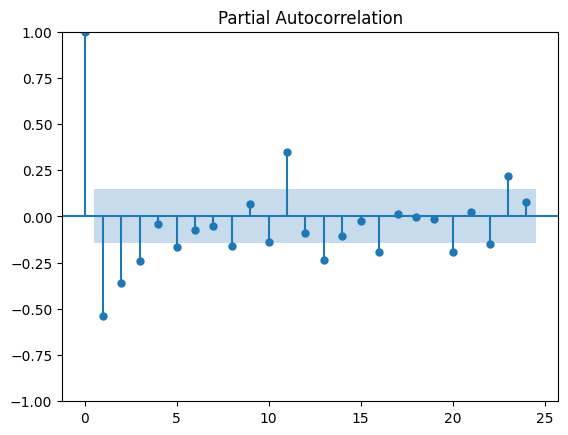

In [ ]:
diff_series = train_x['Sales'].diff().diff(12).dropna()

# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_pacf(diff_series, lags=24)
plt.show()

<Axes: xlabel='DATE'>

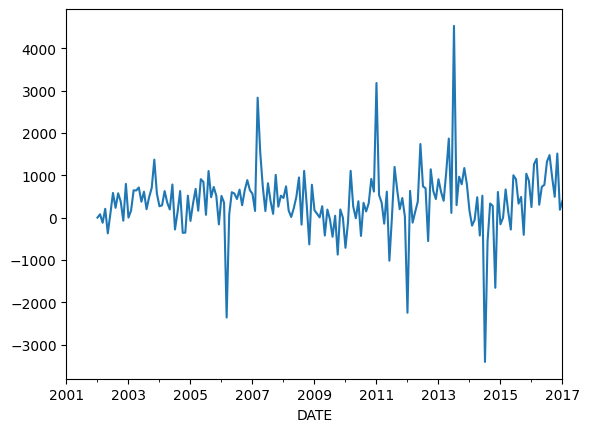

In [ ]:
train_x.Sales.diff(12).plot()

In [ ]:
from statsmodels.tsa.stattools import adfuller

adfuller(train_x.Sales.diff(12).dropna())[1]

np.float64(8.898139629103232e-06)

# For seasonal order , look at lag 12,24,36 etc

<Figure size 800x400 with 0 Axes>

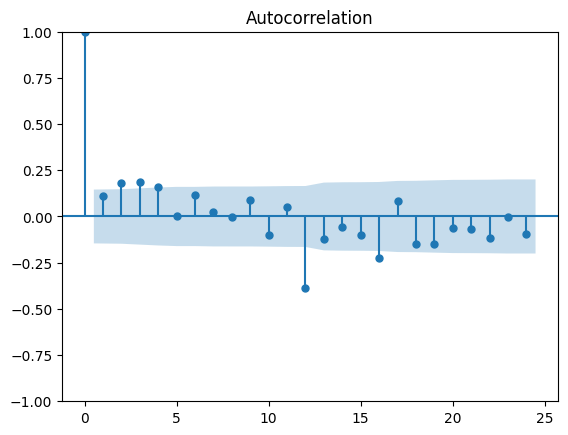

In [ ]:
diff_series = train_x['Sales'].diff(12).dropna()

# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_acf(diff_series, lags=24)
plt.show()

<Figure size 800x400 with 0 Axes>

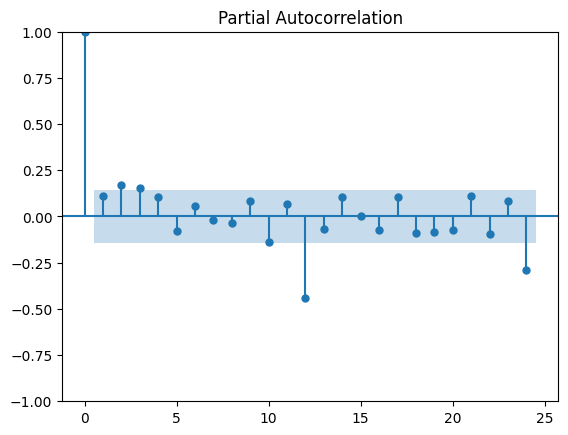

In [ ]:
diff_series = train_x['Sales'].diff(12).dropna()

# 2. Plot PACF
plt.figure(figsize=(8,4))
plot_pacf(diff_series, lags=24)
plt.show()

In [ ]:
model = SARIMAX(train_x.Sales, order=(5, 1, 1),seasonal_order=(2,1,1,12))
model = model.fit(disp=False)

# Step 3: Optional - one-step forecast
forecast_1 = model.forecast(steps=24)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


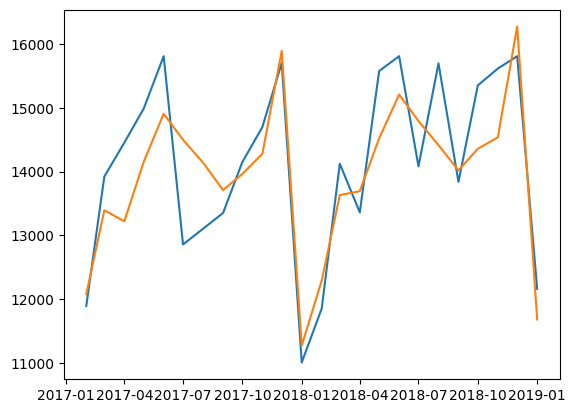

In [ ]:
plt.plot(test_x,label='test_actual')
plt.plot(forecast_1, label='test_pred')